# Predicting Cardiovascular Disease

A practice project on **binary classification**. Given basic medical data about a patient, I predict whether
they have a cardiovascular disease (`cardio = 1`) or not (`cardio = 0`).

What I did, step by step:

1. Loaded the data and looked at the class balance and the raw feature distributions.
2. Engineered clearer features: age in years, BMI, a binary `male` flag.
3. Removed obviously wrong records (impossible blood pressure, height and weight).
4. Used **bootstrap** to build confidence intervals for the mean systolic pressure of sick and healthy patients.
5. Built a **logistic regression** baseline inside a `Pipeline`, tuned `C` and interpreted the coefficients.
6. Trained a **Random Forest**, diagnosed overfitting and fixed it with a grid search.
7. Compared both models on a held-out test set (ROC AUC, ROC curves, confusion matrices).
8. Compared impurity-based and permutation feature importance.
9. Checked which models actually benefit from **bagging** and why.

Main metric: **ROC AUC**. All tuning was done with 5-fold stratified cross-validation on the training part only;
the test set was touched once, at the very end.

### Data

[mlbootcamp5_train.csv](https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/mlbootcamp5_train.csv)
from [mlcourse.ai](https://mlcourse.ai): 70 000 patients, 11 features and the target.

| Feature | Meaning |
|---|---|
| `age` | age **in days** |
| `gender` | 1 = female, 2 = male |
| `height` | height, cm |
| `weight` | weight, kg |
| `ap_hi` | systolic blood pressure |
| `ap_lo` | diastolic blood pressure |
| `cholesterol` | 1 = normal, 2 = above normal, 3 = well above normal |
| `gluc` | glucose: 1, 2, 3 (same scale) |
| `smoke`, `alco`, `active` | smokes / drinks alcohol / physically active (0 or 1) |
| **`cardio`** | **target**: 1 = has a cardiovascular disease |

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#8a8984"
CLASS_COLORS = {0: BLUE, 1: ORANGE}
CLASS_NAMES = {0: "healthy", 1: "sick"}

## 1. Loading the data

In [2]:
data_path = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/mlbootcamp5_train.csv"
df = pd.read_csv(data_path, sep=";", index_col="id")
print(df.shape)
print(df["cardio"].value_counts(normalize=True))
df.head()

(70000, 12)
cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
id,,,,,,,,,,,,
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
age,70000.0,19468.9,2467.3,10798.0,17664.0,19703.0,21327.0,23713.0
gender,70000.0,1.3,0.5,1.0,1.0,1.0,2.0,2.0
height,70000.0,164.4,8.2,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.2,14.4,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.8,154.0,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.6,188.5,-70.0,80.0,80.0,90.0,11000.0
cholesterol,70000.0,1.4,0.7,1.0,1.0,1.0,2.0,3.0
gluc,70000.0,1.2,0.6,1.0,1.0,1.0,1.0,3.0
smoke,70000.0,0.1,0.3,0.0,0.0,0.0,0.0,1.0
alco,70000.0,0.1,0.2,0.0,0.0,0.0,0.0,1.0


The dataset has 70 000 rows and 12 columns. The classes are almost perfectly **balanced** (50.0% / 50.0%),
so even accuracy would be a fair metric here, but I used ROC AUC everywhere because it evaluates the predicted
probabilities rather than one fixed threshold.

The summary table already shows that the data is dirty: `ap_hi` goes from −150 to 16 020, `ap_lo` up to 11 000,
`height` starts at 55 cm and `weight` at 10 kg. I clean this in step 3.

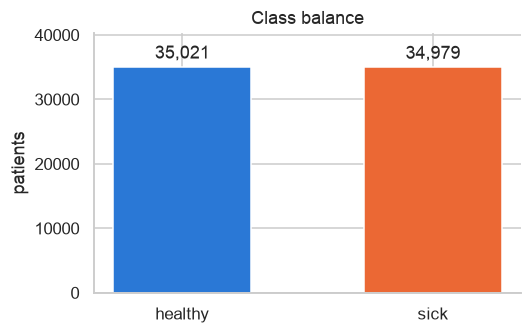

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.2))
counts = df["cardio"].value_counts().sort_index()
bars = ax.bar([CLASS_NAMES[c] for c in counts.index], counts.values,
              color=[CLASS_COLORS[c] for c in counts.index], width=0.55)
ax.bar_label(bars, labels=[f"{v:,}" for v in counts.values], padding=3)
ax.set_title("Class balance")
ax.set_ylabel("patients")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

## 2. Feature engineering

I replaced raw columns with features that are easier to read for both the model and a human:

- `age_years` = age in days / 365.25;
- `bmi` = weight / (height in metres)², which combines height and weight into one meaningful number;
- `male` = 1 for men, 0 for women;
- dropped the original `age` and `gender`.

In [5]:
df["age_years"] = df["age"] / 365.25
df["bmi"] = df["weight"] / (df["height"] / 100) ** 2
df["male"] = df["gender"] - 1
df = df.drop(columns=["age", "gender"])
print(df[["age_years", "bmi", "male"]].mean().round(2))

age_years    53.30
bmi          27.56
male          0.35
dtype: float64


The average patient is 53 years old with a BMI of 27.6 (slightly above the normal range of 18.5–25); 35% of the
patients are men.

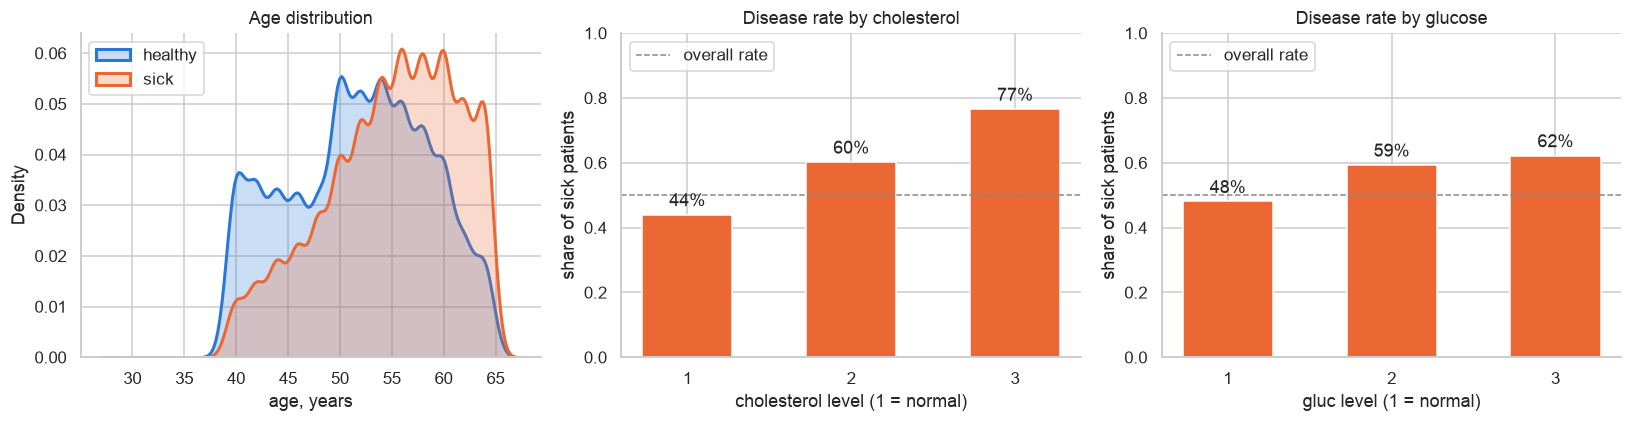

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls in (0, 1):
    sns.kdeplot(df.loc[df["cardio"] == cls, "age_years"], ax=axes[0], color=CLASS_COLORS[cls],
                fill=True, alpha=0.25, linewidth=2, label=CLASS_NAMES[cls])
axes[0].set_title("Age distribution")
axes[0].set_xlabel("age, years")
axes[0].legend()

for ax, col, title in [(axes[1], "cholesterol", "Disease rate by cholesterol"),
                       (axes[2], "gluc", "Disease rate by glucose")]:
    rate = df.groupby(col)["cardio"].mean()
    bars = ax.bar(rate.index.astype(str), rate.values, color=ORANGE, width=0.55)
    ax.bar_label(bars, labels=[f"{v:.0%}" for v in rate.values], padding=3)
    ax.axhline(df["cardio"].mean(), color=GRAY, linestyle="--", linewidth=1, label="overall rate")
    ax.set_title(title)
    ax.set_xlabel(f"{col} level (1 = normal)")
    ax.set_ylabel("share of sick patients")
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

What I saw in the plots:

- **Age** clearly shifts the risk: below ~50 healthy patients dominate, above ~55 sick ones do.
- **Cholesterol** has a strong monotonic effect: 44% sick at the normal level vs 77% at the highest level.
- **Glucose** goes in the same direction but the effect is weaker (48% → 62%).

## 3. Cleaning outliers

The summary table shows obvious input errors: negative pressure, pressure in the thousands, 55 cm tall adults,
diastolic pressure higher than systolic. I kept only the rows where **all** of these hold:

- `ap_hi` between 80 and 220;
- `ap_lo` between 40 and 160;
- `ap_lo <= ap_hi`;
- `height` between 130 and 210;
- `weight` between 35 and 200.

In [7]:
mask = (df["ap_hi"].between(80, 220) & df["ap_lo"].between(40, 160) & (df["ap_lo"] <= df["ap_hi"])
        & df["height"].between(130, 210) & df["weight"].between(35, 200))
df = df[mask]
print(len(df), round(len(df) / 70000, 4))

68553 0.9793


I kept 68 553 rows, i.e. I removed about **2%** of the data. That is a reasonable price for getting rid of
physically impossible values; if the rules had removed 30% of rows, they would have been too strict.

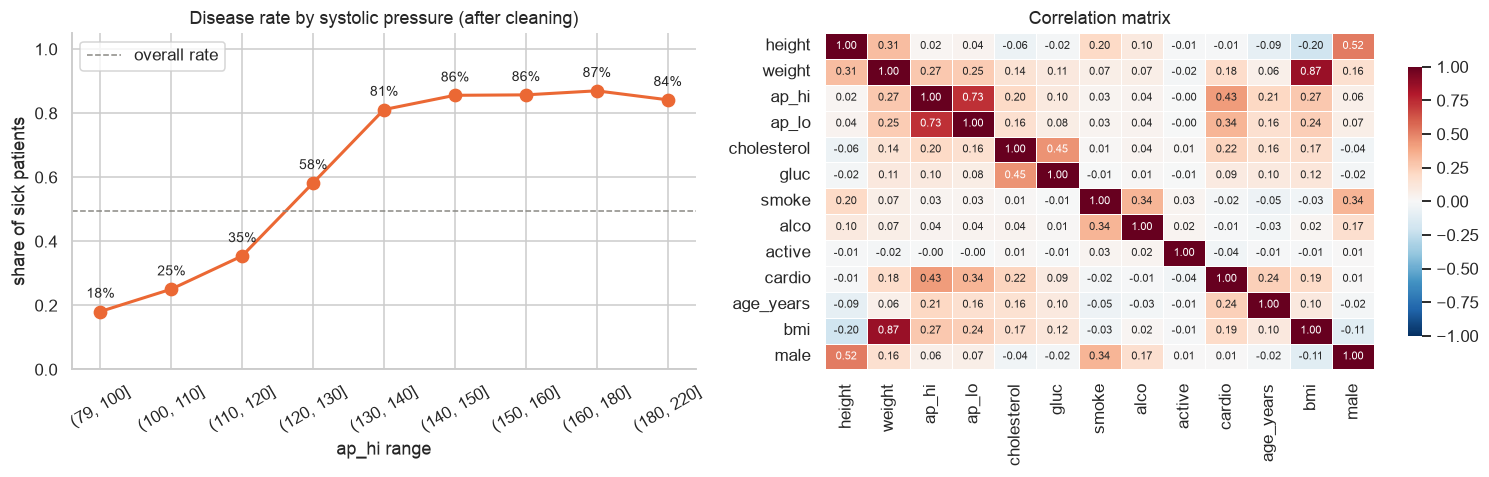

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 1.1]})

ap_bins = pd.cut(df["ap_hi"], bins=[79, 100, 110, 120, 130, 140, 150, 160, 180, 220])
ap_rate = df.groupby(ap_bins, observed=True)["cardio"].agg(["mean", "size"])
axes[0].plot(ap_rate.index.astype(str), ap_rate["mean"], marker="o", markersize=8, color=ORANGE, linewidth=2)
for x, (rate, n) in enumerate(ap_rate.values):
    axes[0].annotate(f"{rate:.0%}", (x, rate), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9)
axes[0].axhline(df["cardio"].mean(), color=GRAY, linestyle="--", linewidth=1, label="overall rate")
axes[0].set_title("Disease rate by systolic pressure (after cleaning)")
axes[0].set_xlabel("ap_hi range")
axes[0].set_ylabel("share of sick patients")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(loc="upper left")

corr = df.corr()
sns.heatmap(corr, ax=axes[1], cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7}, linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1].set_title("Correlation matrix")

plt.tight_layout()
plt.show()

- The disease rate climbs steeply with systolic pressure: 18% at ≤ 100 mmHg, 35% at 110–120, 58% at 120–130 and
  81% at 130–140, after which it levels off at ~85%. This already hints that `ap_hi` will be the key feature.
- In the correlation matrix `cardio` correlates most with `ap_hi` (0.43), `ap_lo` (0.34), `age_years` (0.24) and
  `cholesterol` (0.22).
- Some features are strongly correlated with each other: `ap_hi`–`ap_lo` (0.73) and `weight`–`bmi` (0.87).
  This becomes important when I look at feature importance in step 11.

## 4. Bootstrap: systolic pressure of sick vs healthy patients

I built **95%** confidence intervals for the mean `ap_hi` in each group using 1000 bootstrap samples
(`np.random.seed(0)`).

In [9]:
def get_bootstrap_samples(data, n_samp):
    indices = np.random.randint(0, len(data), (n_samp, len(data)))
    return data[indices]


def stat_intervals(stat, alpha):
    return np.percentile(stat, [100 * alpha / 2.0, 100 * (1 - alpha / 2.0)])


sick = df.loc[df["cardio"] == 1, "ap_hi"].values
healthy = df.loc[df["cardio"] == 0, "ap_hi"].values

np.random.seed(0)
sick_mean = [s.mean() for s in get_bootstrap_samples(sick, 1000)]
np.random.seed(0)
healthy_mean = [s.mean() for s in get_bootstrap_samples(healthy, 1000)]

print("sick:    ", stat_intervals(sick_mean, 0.05).round(2))
print("healthy: ", stat_intervals(healthy_mean, 0.05).round(2))

sick:     [133.69 134.05]
healthy:  [119.48 119.74]


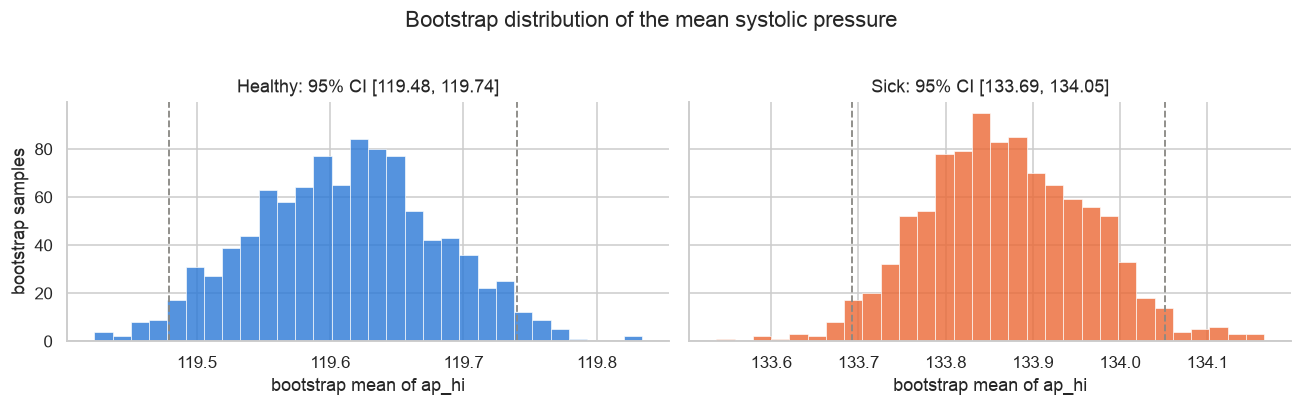

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, cls, means in [(axes[0], 0, healthy_mean), (axes[1], 1, sick_mean)]:
    lo, hi = stat_intervals(means, 0.05)
    ax.hist(means, bins=30, color=CLASS_COLORS[cls], alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.axvline(lo, color=GRAY, linestyle="--", linewidth=1.2)
    ax.axvline(hi, color=GRAY, linestyle="--", linewidth=1.2)
    ax.set_title(f"{CLASS_NAMES[cls].capitalize()}: 95% CI [{lo:.2f}, {hi:.2f}]")
    ax.set_xlabel("bootstrap mean of ap_hi")
axes[0].set_ylabel("bootstrap samples")
fig.suptitle("Bootstrap distribution of the mean systolic pressure", y=1.02)
plt.tight_layout()
plt.show()

The 95% intervals are **[133.69, 134.05]** for sick patients and **[119.48, 119.74]** for healthy ones.
They are very narrow (tens of thousands of patients per group) and about 14 mmHg apart, so they do not overlap at
all: the difference in mean systolic pressure is real and not a sampling artefact.

## 5. Train / test split

I split the data 70/30 with `stratify=y`, so the share of sick patients is the same in both parts.
From here on, all training and tuning happen on `X_train` only.

In [11]:
X = df.drop(columns="cardio")
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17, stratify=y)
print(X_train.shape, X_test.shape, round(y_train.mean(), 4))

(47987, 12) (20566, 12) 0.4947


## 6. Baseline: logistic regression

I put `StandardScaler` and `LogisticRegression` into one `Pipeline`, so the scaler is refitted on every training
fold and no information leaks into validation. The same `StratifiedKFold` object is reused for every model below.

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
logit_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
scores = cross_val_score(logit_pipe, X_train, y_train, cv=skf, scoring="roc_auc")
print(scores.round(4), "mean:", scores.mean().round(4), "std:", scores.std().round(4))

[0.7922 0.7914 0.7909 0.7983 0.7895] mean: 0.7925 std: 0.0031


The baseline logistic regression gets **ROC AUC = 0.7925** on 5-fold CV. The spread between folds is small
(std ≈ 0.003), so the estimate is reliable. Everything below is compared against this number.

## 7. Tuning the regularization strength `C`

Grid: `np.logspace(-3, 2, 6)`. Inside a pipeline the parameter name is `<step name>__<param>`.

In [13]:
logit_grid = GridSearchCV(logit_pipe, {"logisticregression__C": np.logspace(-3, 2, 6)},
                          scoring="roc_auc", cv=skf, n_jobs=-1)
logit_grid.fit(X_train, y_train)
print(logit_grid.best_params_, round(logit_grid.best_score_, 4),
      round(logit_grid.cv_results_["std_test_score"][logit_grid.best_index_], 4))

{'logisticregression__C': np.float64(0.1)} 0.7925 0.003


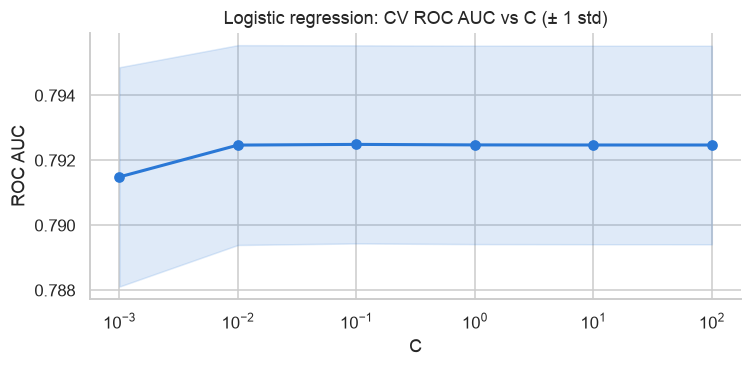

In [14]:
res = pd.DataFrame(logit_grid.cv_results_)
c_values = res["param_logisticregression__C"].astype(float)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(c_values, res["mean_test_score"], marker="o", color=BLUE, linewidth=2)
ax.fill_between(c_values, res["mean_test_score"] - res["std_test_score"],
                res["mean_test_score"] + res["std_test_score"], color=BLUE, alpha=0.15)
ax.set_xscale("log")
ax.set_title("Logistic regression: CV ROC AUC vs C (± 1 std)")
ax.set_xlabel("C")
ax.set_ylabel("ROC AUC")
plt.tight_layout()
plt.show()

The best value is `C = 0.1` with ROC AUC 0.7925, which is the same as the default `C = 1`. The curve is flat
everywhere except the strongest regularization (`C = 0.001`). With 12 features and ~48 000 objects a linear model
has nothing to overfit to: its limitation here is not variance but **simplicity** (bias).

## 8. Interpreting the logistic regression

Features inside the pipeline are standardized, so each weight means "change in log-odds per one standard deviation".
To get the effect of **+10 years** I divided the `age_years` weight by its std from the scaler and multiplied by 10.

In [15]:
best = logit_grid.best_estimator_
lr = best.named_steps["logisticregression"]
sc = best.named_steps["standardscaler"]

coef = pd.DataFrame({"coef": lr.coef_[0], "abs": np.abs(lr.coef_[0])}, index=X_train.columns)
coef = coef.sort_values("abs", ascending=False)
print(coef.round(3))

i = list(X_train.columns).index("age_years")
print("\nodds multiplier for +10 years:", round(np.exp(lr.coef_[0][i] / sc.scale_[i] * 10), 2))

              coef    abs
ap_hi        0.941  0.941
cholesterol  0.348  0.348
age_years    0.348  0.348
ap_lo        0.102  0.102
active      -0.090  0.090
weight       0.085  0.085
bmi          0.072  0.072
gluc        -0.067  0.067
smoke       -0.043  0.043
alco        -0.041  0.041
height       0.008  0.008
male        -0.008  0.008

odds multiplier for +10 years: 1.67


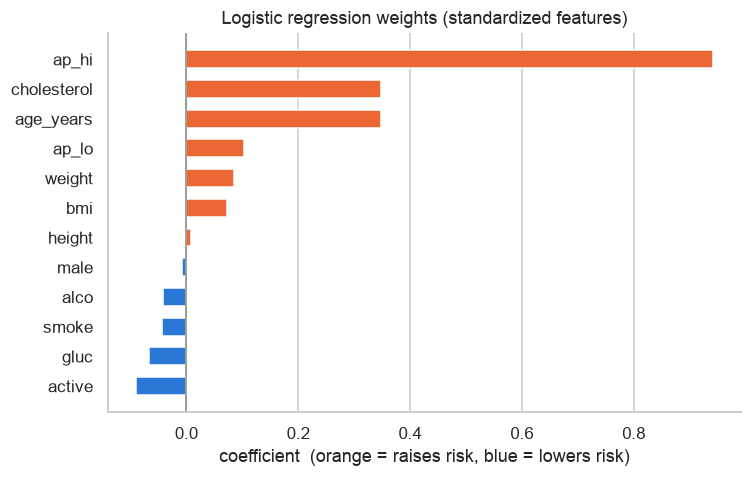

In [16]:
plot_coef = coef.sort_values("coef")
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(plot_coef.index, plot_coef["coef"], color=[ORANGE if c > 0 else BLUE for c in plot_coef["coef"]], height=0.6)
ax.axvline(0, color=GRAY, linewidth=1)
ax.set_title("Logistic regression weights (standardized features)")
ax.set_xlabel("coefficient  (orange = raises risk, blue = lowers risk)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

- The three most influential features are **`ap_hi`**, **`cholesterol`** and **`age_years`**, which matches medical
  intuition.
- `active` has a **negative** weight: physically active people are less likely to be sick.
- Being **10 years older** multiplies the odds of the disease by **≈ 1.67**, i.e. the odds grow by about 67%.
- `smoke` and `alco` also got negative weights, although smoking is obviously harmful. These columns are
  self-reported, and the answers are known to be unreliable in this dataset. The lesson: model weights show
  **association in the data, not causation**.

## 9. Random Forest

### 9a. Out of the box

`RandomForestClassifier(n_estimators=100, oob_score=True)` with default settings: trees grow until the leaves are pure.

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=17, n_jobs=-1, oob_score=True)
rf.fit(X_train, y_train)

rf_train_auc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
rf_cv_auc = cross_val_score(rf, X_train, y_train, cv=skf, scoring="roc_auc").mean()
print("train ROC AUC:", round(rf_train_auc, 4))
print("CV ROC AUC:   ", round(rf_cv_auc, 4))
print("OOB accuracy: ", round(rf.oob_score_, 4))

train ROC AUC: 1.0
CV ROC AUC:    0.7747
OOB accuracy:  0.7103


ROC AUC on train is **1.0**, while on CV it is only **0.775**. This huge gap is classic **overfitting**: fully grown
trees memorise every patient. Out of the box the forest is even **worse** than the logistic regression
(0.775 vs 0.7925). The OOB accuracy (≈ 0.71) confirms this: on the objects each tree did not see, the quality is
far below the training score.

### 9b. Tuning the forest

Grid: `max_depth` [6, 8, 10, 12], `min_samples_leaf` [10, 30], `max_features` [2, 4] (16 combinations).

In [18]:
rf_grid = GridSearchCV(RandomForestClassifier(n_estimators=100, random_state=17, n_jobs=-1),
                       {"max_depth": [6, 8, 10, 12], "min_samples_leaf": [10, 30], "max_features": [2, 4]},
                       scoring="roc_auc", cv=skf, n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(rf_grid.best_params_, round(rf_grid.best_score_, 4))

{'max_depth': 10, 'max_features': 4, 'min_samples_leaf': 10} 0.801


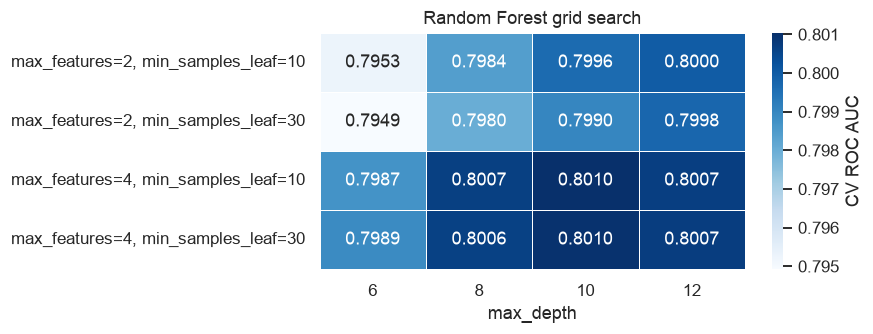

In [19]:
rf_res = pd.DataFrame(rf_grid.cv_results_)
rf_res["setting"] = ("max_features=" + rf_res["param_max_features"].astype(str)
                     + ", min_samples_leaf=" + rf_res["param_min_samples_leaf"].astype(str))
pivot = rf_res.pivot(index="setting", columns="param_max_depth", values="mean_test_score")

fig, ax = plt.subplots(figsize=(8, 3.2))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="Blues", linewidths=0.5, cbar_kws={"label": "CV ROC AUC"}, ax=ax)
ax.set_title("Random Forest grid search")
ax.set_xlabel("max_depth")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

The best combination is `max_depth=10`, `max_features=4`, `min_samples_leaf=10` with **CV ROC AUC = 0.801**.
Limiting tree depth and leaf size removed the overfitting, raised CV ROC AUC by about 0.026 and put the forest
ahead of the logistic regression. Shallow trees (`max_depth=6`) underfit slightly, and `max_features=4`
consistently beats `max_features=2`.

## 10. Final check on the test set

Only now I used the held-out test set: ROC AUC, ROC curves and confusion matrices (threshold 0.5)
for the best logistic regression and the best forest.

In [20]:
proba_lr = logit_grid.predict_proba(X_test)[:, 1]
proba_rf = rf_grid.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, proba_lr)
auc_rf = roc_auc_score(y_test, proba_rf)
print("LogReg test ROC AUC:", round(auc_lr, 4), "| accuracy:", round(accuracy_score(y_test, proba_lr > 0.5), 4))
print("RF     test ROC AUC:", round(auc_rf, 4), "| accuracy:", round(accuracy_score(y_test, proba_rf > 0.5), 4))
print("difference:", round(auc_rf - auc_lr, 4))

LogReg test ROC AUC: 0.7881 | accuracy: 0.7255
RF     test ROC AUC: 0.798 | accuracy: 0.7331
difference: 0.0099


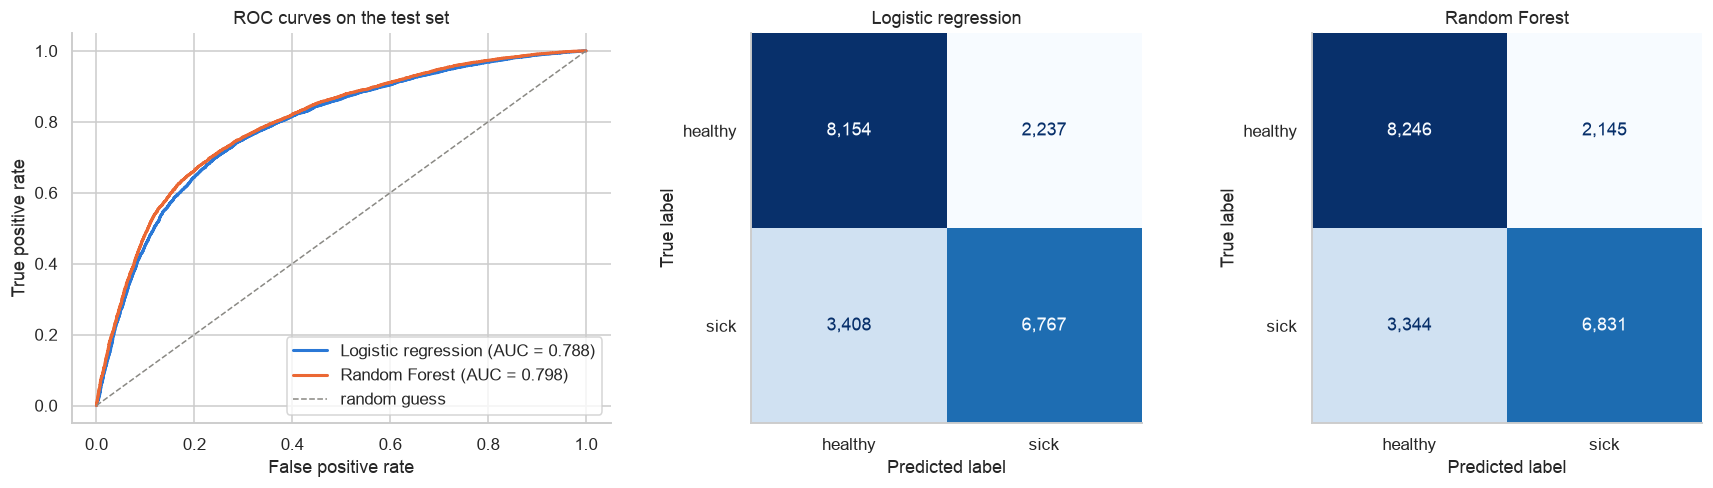

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1.2, 1, 1]})

for name, proba, auc, color in [("Logistic regression", proba_lr, auc_lr, BLUE),
                                ("Random Forest", proba_rf, auc_rf, ORANGE)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1, label="random guess")
axes[0].set_title("ROC curves on the test set")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(loc="lower right")

for ax, name, proba in [(axes[1], "Logistic regression", proba_lr), (axes[2], "Random Forest", proba_rf)]:
    ConfusionMatrixDisplay.from_predictions(y_test, (proba > 0.5).astype(int), display_labels=["healthy", "sick"],
                                            cmap="Blues", colorbar=False, ax=ax, values_format=",")
    ax.set_title(name)
    ax.grid(False)

plt.tight_layout()
plt.show()

| Model | CV ROC AUC | Test ROC AUC | Test accuracy |
|---|---|---|---|
| Logistic regression (C = 0.1) | 0.7925 | 0.7881 | 0.7255 |
| Random Forest (tuned) | 0.8010 | **0.7980** | **0.7331** |

- The test scores are very close to the CV scores, so cross-validation gave an honest estimate and I did not
  overfit to the validation folds while tuning.
- The forest is better by about **0.01 ROC AUC**. The gap is small because the main dependencies here are close to
  linear (higher pressure → higher risk), so a simple model is almost as good as a complex one.
- The ROC curves almost coincide. Both models miss about a third of sick patients at the default 0.5 threshold;
  in a real screening setting I would lower the threshold to trade more false alarms for fewer missed cases.

## 11. Feature importance of the forest

I compared two ways to measure importance for the best forest:

1. `feature_importances_`: impurity decrease accumulated over all splits;
2. `permutation_importance` on the **test** set: how much ROC AUC drops when a feature is shuffled.

In [22]:
best_rf = rf_grid.best_estimator_
imp = pd.DataFrame({"impurity": best_rf.feature_importances_}, index=X_train.columns)
pi = permutation_importance(best_rf, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=17, n_jobs=-1)
imp["permutation"] = pi.importances_mean
imp = imp.sort_values("permutation", ascending=False)
imp.round(4)

,impurity,permutation
ap_hi,0.4627,0.1734
age_years,0.1375,0.0386
cholesterol,0.0933,0.0286
ap_lo,0.1796,0.0056
gluc,0.0092,0.0021
bmi,0.0487,0.0020
active,0.0075,0.0019
weight,0.0333,0.0011
smoke,0.0029,0.0006
male,0.0033,0.0004


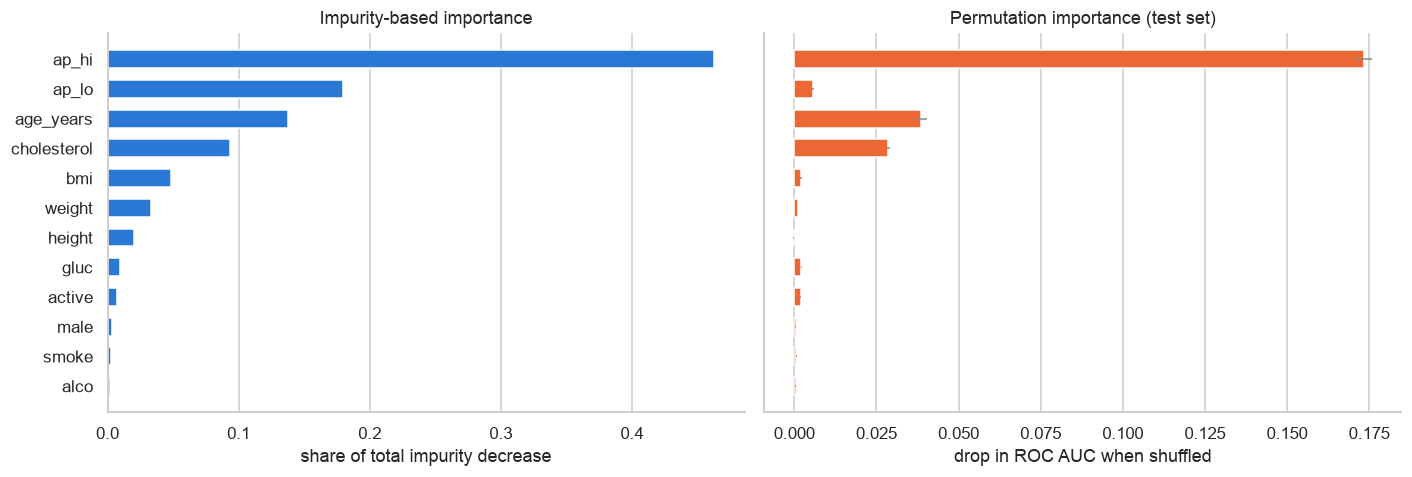

In [23]:
order = imp.sort_values("impurity").index
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
axes[0].barh(order, imp.loc[order, "impurity"], color=BLUE, height=0.6)
axes[0].set_title("Impurity-based importance")
axes[0].set_xlabel("share of total impurity decrease")
axes[1].barh(order, imp.loc[order, "permutation"], xerr=pd.Series(pi.importances_std, index=X_train.columns)[order],
             color=ORANGE, height=0.6, error_kw={"ecolor": GRAY, "linewidth": 1})
axes[1].set_title("Permutation importance (test set)")
axes[1].set_xlabel("drop in ROC AUC when shuffled")
for ax in axes:
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

- Both methods put **`ap_hi`** first by a wide margin, and it is also the top feature of the logistic regression.
  Age and cholesterol follow.
- The interesting difference is `ap_lo`: impurity importance gives it 0.18 (2nd place), while permutation importance
  is almost 0. The reason is the 0.73 correlation with `ap_hi`: when I shuffle `ap_lo`, the forest still gets the
  same information from `ap_hi`, so the quality barely drops. Impurity importance **overrates such duplicated
  features**, permutation importance does not.
- The same effect is visible for `weight`, `height` and `bmi`: they share information, so each of them on its own
  is almost useless once the others are present.

## 12. Who benefits from bagging?

I compared four models with the same CV on the training set: a single unrestricted decision tree, bagging of 50 such
trees, the logistic regression pipeline, and bagging of 50 such pipelines.

In [24]:
models = {
    "decision tree": DecisionTreeClassifier(random_state=17),
    "bagging of trees": BaggingClassifier(DecisionTreeClassifier(random_state=17), n_estimators=50,
                                          random_state=17, n_jobs=-1),
    "logistic regression": logit_pipe,
    "bagging of logregs": BaggingClassifier(logit_pipe, n_estimators=50, random_state=17, n_jobs=-1),
}
bag_scores = {name: cross_val_score(m, X_train, y_train, cv=skf, scoring="roc_auc").mean() for name, m in models.items()}
for name, score in bag_scores.items():
    print(f"{name:22s}", round(score, 4))

decision tree          0.6352
bagging of trees       0.7677
logistic regression    0.7925
bagging of logregs     0.7925


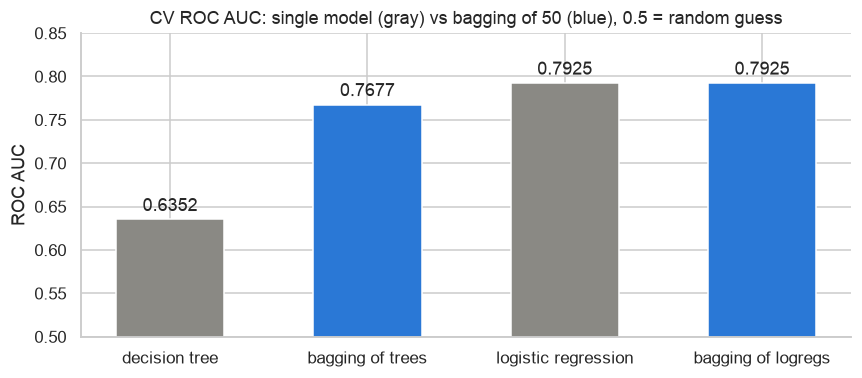

In [25]:
fig, ax = plt.subplots(figsize=(8, 3.6))
names = list(bag_scores)
bars = ax.bar(names, bag_scores.values(), color=[GRAY, BLUE, GRAY, BLUE], width=0.55)
ax.bar_label(bars, labels=[f"{v:.4f}" for v in bag_scores.values()], padding=3)
ax.set_ylim(0.5, 0.85)
ax.set_title("CV ROC AUC: single model (gray) vs bagging of 50 (blue), 0.5 = random guess")
ax.set_ylabel("ROC AUC")
plt.tight_layout()
plt.show()

- A single unrestricted tree: **0.635**. It has very high **variance** and memorises noise.
- Bagging of 50 such trees: **0.768**, a huge gain, because averaging many decorrelated trees cancels out variance.
- Logistic regression: **0.7925**, bagging of 50 logistic regressions: **0.7925**, no gain at all.

Bagging reduces only variance. A logistic regression is a stable, low-variance model: on every bootstrap sample it
learns almost the same weights, so there is nothing to average out. Bagging helps unstable models like deep trees
and does nothing for stable ones.

## 13. Summary

In [26]:
summary = pd.DataFrame({
    "CV ROC AUC": [scores.mean(), logit_grid.best_score_, rf_cv_auc, rf_grid.best_score_,
                   bag_scores["decision tree"], bag_scores["bagging of trees"], bag_scores["bagging of logregs"]],
    "test ROC AUC": [np.nan, auc_lr, np.nan, auc_rf, np.nan, np.nan, np.nan],
}, index=["LogReg (C=1)", "LogReg (tuned C)", "RF (default)", "RF (tuned)",
          "Decision tree", "Bagging of trees", "Bagging of logregs"])
summary.sort_values("CV ROC AUC", ascending=False).round(4)

,CV ROC AUC,test ROC AUC
RF (tuned),0.8010,0.7980
LogReg (tuned C),0.7925,0.7881
Bagging of logregs,0.7925,NaN
LogReg (C=1),0.7925,NaN
RF (default),0.7747,NaN
Bagging of trees,0.7677,NaN
Decision tree,0.6352,NaN


### Conclusions

1. **The best model is the tuned Random Forest**: ROC AUC 0.798 on the test set vs 0.788 for the logistic regression.
   The difference is small, because the key dependencies in this data are close to linear.
2. **Systolic pressure, age and cholesterol** are the strongest predictors of cardiovascular disease. Both models
   agree on that, and the bootstrap confirms that the pressure gap between sick and healthy patients is real
   (non-overlapping 95% intervals: ~134 vs ~120 mmHg).
3. **Train / CV / test comparison**: the default forest overfits heavily (train 1.0 vs CV 0.775). After limiting depth
   and leaf size, CV (0.801) and test (0.798) agree, so the final model does not overfit and CV is a trustworthy
   estimate.
4. **Bagging** dramatically improves unstable high-variance models (single tree 0.635 → 0.768) and gives nothing to
   stable ones (logistic regression 0.7925 → 0.7925).
5. **Impurity-based importance** can be misleading for correlated features (`ap_lo` looks important only because it
   duplicates `ap_hi`); **permutation importance** on held-out data gives a more honest picture.